In [77]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'src'))

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import numpy as np

df = pd.read_csv("../data/processed/trivsel_fravaer_merged.csv")
df_uddannelse = pd.read_csv("../data/processed/uddannelse_score.csv")
df.head()

,kommune,klassetrin,skoleår,fravaer_pct,trivsel_score
0,Aabenraa,Mellemtrin,2024/2025,6.6,3.667768
1,Aabenraa,Udskoling,2024/2025,7.7,3.524200
2,Aalborg,Mellemtrin,2024/2025,8.9,3.718750
3,Aalborg,Udskoling,2024/2025,9.9,3.573500
4,Aarhus,Mellemtrin,2024/2025,6.4,3.733033


In [78]:
df.shape

(196, 5)

Lav en samlet dataframe som også inkluderer uddannelsesniveau

In [79]:
df = df.merge(df_uddannelse, on=['kommune', 'klassetrin'], how='inner')
print(df.shape)
df.head()

(196, 6)


,kommune,klassetrin,skoleår,fravaer_pct,trivsel_score,foraeldre_uddannelsesniveau
0,Aabenraa,Mellemtrin,2024/2025,6.6,3.667768,4.837537
1,Aabenraa,Udskoling,2024/2025,7.7,3.524200,4.880469
2,Aalborg,Mellemtrin,2024/2025,8.9,3.718750,5.503681
3,Aalborg,Udskoling,2024/2025,9.9,3.573500,5.462928
4,Aarhus,Mellemtrin,2024/2025,6.4,3.733033,5.758373


## Visualisering

Start med at visualisere data for at få overblik over eventuelle mønstre og sammenhænge. Udregn også korrelationen mellem fravær og trivsel. 

Korrelation: -0.49


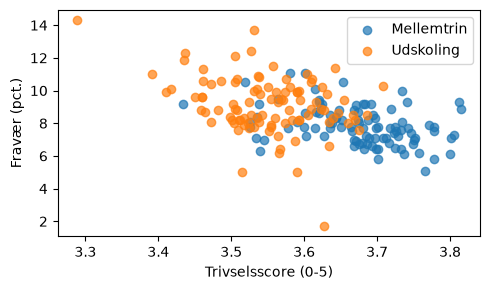

In [80]:
corr = df['trivsel_score'].corr(df['fravaer_pct'])
print(f"Korrelation: {corr:.2f}")

plt.figure(figsize=(5, 3))
for gruppe, data in df.groupby('klassetrin'):
    plt.scatter(data['trivsel_score'], data['fravaer_pct'], label=gruppe, alpha=0.7)

plt.xlabel('Trivselsscore (0-5)')
plt.ylabel('Fravær (pct.)')
#plt.title(f'Trivsel vs. fravær pr. kommune (2024/2025)\nKorrelation: {corr:.2f}')
plt.legend()
plt.tight_layout()
plt.savefig('trivsel_fravaer_scatter.png', dpi=150)
plt.show()

In [81]:
r, p = stats.pearsonr(df['trivsel_score'], df['fravaer_pct'])
print(f"r = {r:.3f}, p = {p}")

r = -0.491, p = 2.6197847411663723e-13


Manglende data

In [82]:
missing = df[['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']].isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)

missing_summary = pd.DataFrame({
    'Antal manglende': missing,
    'Andel manglende (%)': missing_pct
})

display(missing_summary)

,Antal manglende,Andel manglende (%)
trivsel_score,0,0.0
fravaer_pct,0,0.0
foraeldre_uddannelsesniveau,0,0.0


isnull()-tjekket viser ingen manglende værdier, hvilket ikke betyder, at der ikke findes uoplyste data i det oprindelige datasæt, men derimod, at disse allerede er blevet identificeret og håndteret eksplicit som kategorierne 'uoplyst' og 'fejl' tidligere i databehandlingen, snarere end at fremstå som tomme celler.

## Deskriptiv statistik

In [83]:
df[['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']].describe()

,trivsel_score,fravaer_pct,foraeldre_uddannelsesniveau
count,196.000000,196.000000,196.000000
mean,3.611163,8.506633,5.189227
std,0.095320,1.623515,0.408951
min,3.288250,1.700000,4.201087
25%,3.537125,7.575000,4.903189
50%,3.614707,8.300000,5.104776
75%,3.682000,9.400000,5.387329
max,3.814750,14.300000,6.369416


For alle tre datasæt observerer vi at gennemsnit og median ligger tæt på hinanden, hvilket indikerer at der ikke er udtalt skævhed i fordelingerne. 

In [84]:
df.groupby('klassetrin')[['trivsel_score', 'fravaer_pct']].agg(['mean', 'std', 'median'])

trivsel_score                     fravaer_pct                 
                    mean       std    median        mean       std median
klassetrin                                                               
Mellemtrin      3.672894  0.074360  3.680325    7.878571  1.183412    7.8
Udskoling       3.549432  0.070965  3.553201    9.134694  1.761039    8.9

#### Skævhed og kurtosis

In [85]:
skew_kurt = pd.DataFrame({
    'Skævhed': [df[col].skew() for col in ['fravaer_pct', 'trivsel_score', 'foraeldre_uddannelsesniveau']],
    'Kurtosis': [df[col].kurtosis() for col in ['fravaer_pct', 'trivsel_score', 'foraeldre_uddannelsesniveau']]
}, index=['fravaer_pct', 'trivsel_score', 'foraeldre_uddannelsesniveau'])

display(skew_kurt.round(2))


,Skævhed,Kurtosis
fravaer_pct,0.18,1.86
trivsel_score,-0.16,-0.22
foraeldre_uddannelsesniveau,0.91,0.67


Fravær og forældres uddannelsesniveau har en positiv skævhed, og dermed en hale i fordelingen mod højre - mest udtalt for uddannelsesniveau. Omvendt er der en svag tendens til en hale mod venstre i trivselsscore. Derudover har fravær og forældres udd.niveau positiv kurtosis, svarende til flere ekstreme observationer ift. en normalfordeling. Trivsel har negativ kurtosis og dermed en fladere top og færre outliers. Værdierne for skævhed af fravær og skævhed og kurtosis for trivsel er dog så tæt på nul at de indikerer en næsten symmetrisk fordeling

#### Korrelationer

In [86]:
df[['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']].corr()

,trivsel_score,fravaer_pct,foraeldre_uddannelsesniveau
trivsel_score,1.000000,-0.491368,0.376540
fravaer_pct,-0.491368,1.000000,-0.151332
foraeldre_uddannelsesniveau,0.376540,-0.151332,1.000000


In [87]:
r, p = stats.pearsonr(df['trivsel_score'], df['foraeldre_uddannelsesniveau'])
print(f"r = {r:.3f}, p = {p}")

r, p = stats.pearsonr(df['fravaer_pct'], df['foraeldre_uddannelsesniveau'])
print(f"r = {r:.3f}, p = {p}")

r = 0.377, p = 5.346794358064816e-08
r = -0.151, p = 0.03423405177216639


#### Plots

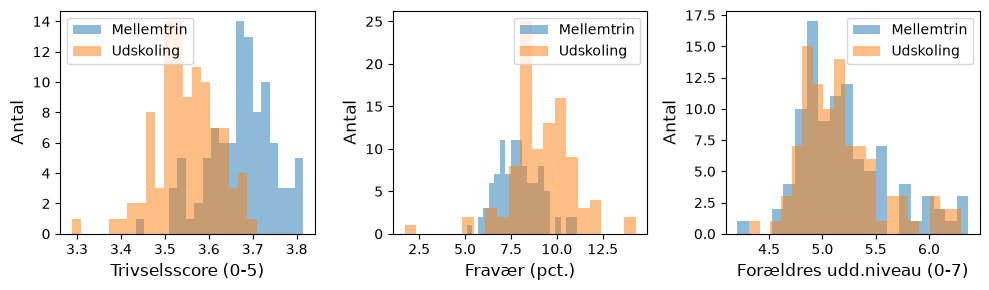

In [88]:
# Histogrammer over fordelinger af trivsel, fravær og uddannelseniveau for mellemtrin og udskoling

variables = ['trivsel_score', 'fravaer_pct', 'foraeldre_uddannelsesniveau']

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, var in zip(axes, variables):
    for klasse, color in zip(['Mellemtrin', 'Udskoling'], ['tab:blue', 'tab:orange']):
        data = df[df['klassetrin'] == klasse][var]
        ax.hist(data, bins=20, alpha=0.5, label=klasse, color=color)
    ax.set_ylabel('Antal', fontsize=12)
    ax.legend()

axes[0].set_xlabel('Trivselsscore (0-5)', fontsize=12);axes[1].set_xlabel('Fravær (pct.)', fontsize=12);axes[2].set_xlabel('Forældres udd.niveau (0-7)', fontsize=12)

plt.tight_layout()
plt.savefig('descriptive_distributions.png', dpi=150)
plt.show()

Histogrammerne viser for alle tre variable og begge klassetrin fordelinger uden udtalt skævhed, bortset fra forældres uddannelsesniveau som har en hale mod høje uddannelsesniveauer. For trivselsscore har mellemtrinnets fordeling toppunkt ved højere værdier, mens det omvendte gør sig gældende for fravær. Vi ser altså at udskolingen generelt har lavere trivsel og højere fravær end mellemtrinnet, mens forældrenes uddannelsesniveau som forventet er ens for de to skoletrin. 

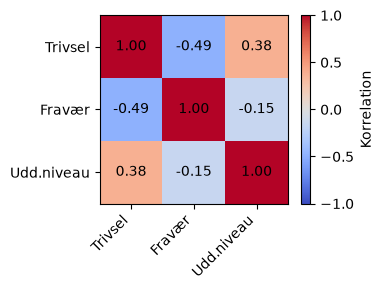

In [89]:
# Korrelationsmatrix

labels = ['Trivsel', 'Fravær', 'Udd.niveau']

corr_matrix = df[variables].corr()

plt.figure(figsize=(4, 3))
im = plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im, label='Korrelation')
plt.xticks(range(len(variables)), labels, rotation=45, ha='right')
plt.yticks(range(len(variables)), labels)

for i in range(len(variables)):
    for j in range(len(variables)):
        plt.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', color='black')


plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

Korrelationsmatricen viser middelstærke korrelationer mellem fravær og trivsel, og trivsel og forældres uddannelsesniveau samt en svag korrelation mellem fravær og forældres uddannelsesniveau. 

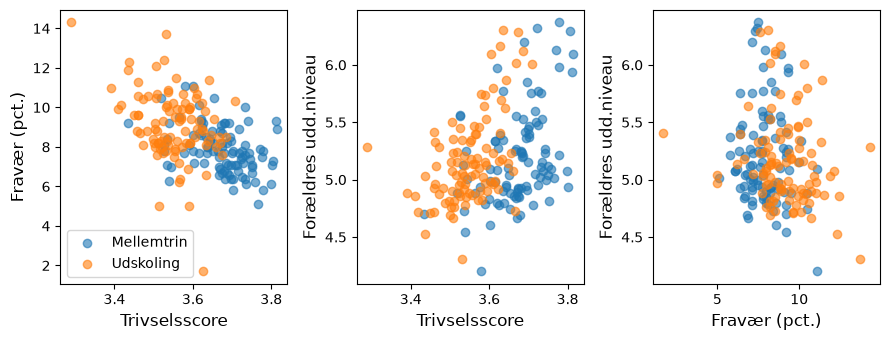

In [90]:
import itertools

pairs = list(itertools.combinations(variables, 2))
colors = {'Mellemtrin': 'tab:blue', 'Udskoling': 'tab:orange'}
labels = {'trivsel_score': 'Trivselsscore', 'fravaer_pct': 'Fravær (pct.)', 'foraeldre_uddannelsesniveau': 'Forældres udd.niveau'}

fig, axes = plt.subplots(1, 3, figsize=(9, 3.5))

for ax, (var1, var2) in zip(axes, pairs):
    for klasse in ['Mellemtrin', 'Udskoling']:
        data = df[df['klassetrin'] == klasse]
        ax.scatter(data[var1], data[var2], alpha=0.6, label=klasse, color=colors[klasse])
    ax.set_xlabel(labels[var1], fontsize=12)
    ax.set_ylabel(labels[var2], fontsize=12)

axes[0].legend()
plt.tight_layout()
plt.savefig('scatter_relationships.png', dpi=150)
plt.show()

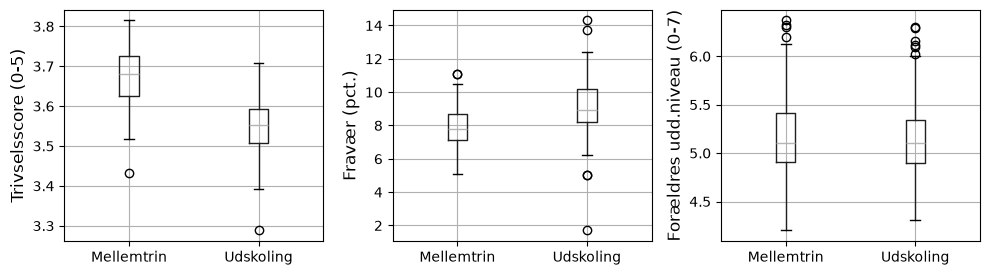

In [91]:
# Boxplots

fig, axes = plt.subplots(1, 3, figsize=(10, 3))

for ax, var in zip(axes, variables):
    df.boxplot(column=var, by='klassetrin', ax=ax)
    ax.set_xlabel('')
    ax.set_title('')

axes[0].set_ylabel('Trivselsscore (0-5)', fontsize=12);axes[1].set_ylabel('Fravær (pct.)', fontsize=12);axes[2].set_ylabel('Forældres udd.niveau (0-7)', fontsize=12)

plt.suptitle('')
plt.tight_layout()
plt.savefig('descriptive_boxplots.png', dpi=150)
plt.show()

Disse boxplots illustrerer igen samme effekter som histogrammerne, idet mellemtrinnet har højere medianværdier for trivsel og lavere for fravær sammenlignet med udskolingen, mens fordelingerne for uddannelsesniveau er tilnærmelsesvist ens på de to skoletrin. Derudover har uddannelsesniveau en del outliers ved høje værdier, hvilket også fremgik af den positive skævhed og kurtosis. De outliers, der bidrog til fraværs udtalte positive kurtosis, er ligeledes tydelige her.

## Lineære regressionsmodeller

Vi finder en negativ korrelation og en p-værdi p<0.0001, hvilket indikerer at korrelationen mellem trivsel og fravær er statistisk signifikant. Fra plottet observeres det at der er kvalitativ forskel på data fra mellemtrin og udskoling, idet udskolingen generelt har en lavere trivsel og et højere fravær end vi ser på mellemtrinet. Dette tyder på at trivslen falder med alderen. 

Vi undersøger nu hvordan sammenhængen er forskellige i de to aldersgrupper ved at lave lineære regressionsmodeller for dem begge.

In [92]:
for gruppe in ['Mellemtrin', 'Udskoling']:
    data = df[df['klassetrin'] == gruppe]
    X = sm.add_constant(data['trivsel_score'])
    y = data['fravaer_pct']
    model = sm.OLS(y, X).fit()
    
    print(f"--- {gruppe} ---")
    print(f"Koefficient: {model.params['trivsel_score']:.4f}")
    print(f"R²: {model.rsquared:.3f}")
    print(f"p-værdi: {model.pvalues['trivsel_score']:.4g}")
    print(f"95% CI: {model.conf_int().loc['trivsel_score'].values}")
    print()

--- Mellemtrin ---
Koefficient: -5.9711
R²: 0.141
p-værdi: 0.0001409
95% CI: [-8.95970368 -2.98244638]

--- Udskoling ---
Koefficient: -8.2422
R²: 0.110
p-værdi: 0.0008342
95% CI: [-12.98430827  -3.50018452]



Resultaterne for mellemtrinnet viser igen en statistisk signifikant (p=0.0001) negativ korrelation mellem høj trivsel og fravær, og R^2=0.14 fortæller at trivslen forklarer cirka 14 % af variationen i fravær. I udskolingen ses samme tendens med en lidt højere p-værdi, p=0.0008, og et bredere konfidensinterval, samt en lidt lavere R^2-værdi på 0.11. 

I udskolingen ser det ud til, at trivsel har en stærkere effekt per procentpoint, men forklarer en mindre del af den samlede variation i fravær. Den lavere forklaringsgrad i udskolingen kan afspejle, at andre faktorer — såvel personlige og sociale forhold i denne aldersgruppe som mulige uobserverede confoundere, der påvirker både trivsel og fravær — får relativt større betydning, efterhånden som eleverne bliver ældre. Sammenhængen bør derfor tolkes korrelationelt og ikke som en kausal effekt


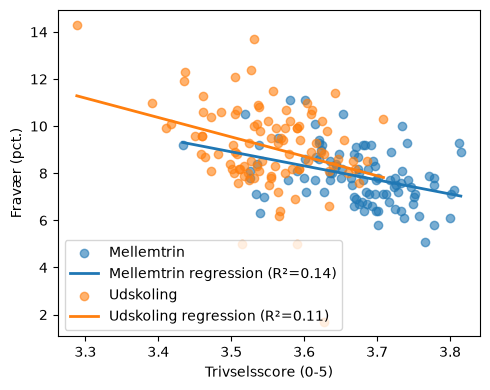

In [93]:
colors = {'Mellemtrin': 'tab:blue', 'Udskoling': 'tab:orange'}

plt.figure(figsize=(5, 4))

for gruppe in ['Mellemtrin', 'Udskoling']:
    data = df[df['klassetrin'] == gruppe]
    
    # scatter
    plt.scatter(data['trivsel_score'], data['fravaer_pct'],
                label=gruppe, alpha=0.6, color=colors[gruppe])
    
    # regression line
    X = sm.add_constant(data['trivsel_score'])
    model = sm.OLS(data['fravaer_pct'], X).fit()
    
    x_range = np.linspace(data['trivsel_score'].min(), data['trivsel_score'].max(), 100)
    y_pred = model.params['const'] + model.params['trivsel_score'] * x_range
    
    plt.plot(x_range, y_pred, color=colors[gruppe], linewidth=2,
              label=f'{gruppe} regression (R²={model.rsquared:.2f})')

plt.xlabel('Trivselsscore (0-5)')
plt.ylabel('Fravær (pct.)')
#plt.title('Trivsel vs. fravær pr. kommune (2024/2025)')
plt.legend()
plt.tight_layout()
plt.savefig('trivsel_fravaer_regression.png', dpi=150)
plt.show()

Text(0.5, 1.0, 'Fordeling af residualer (2024/2025)')

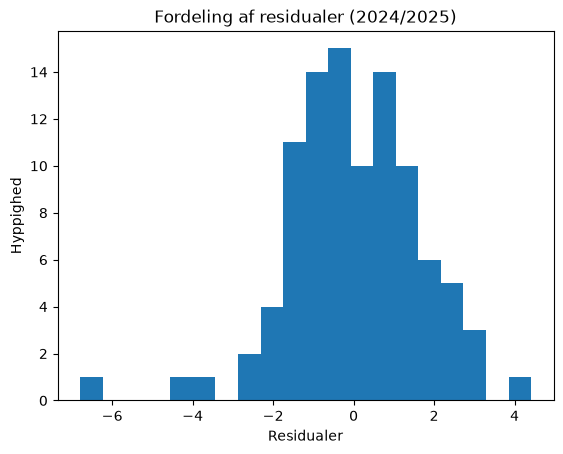

In [94]:
import matplotlib.pyplot as plt

plt.hist(model.resid, bins=20)
plt.xlabel('Residualer')
plt.ylabel('Hyppighed')
plt.title('Fordeling af residualer (2024/2025)')


En visuel inspektion af residualerne viser en tilnærmelsesvis normalfordeling med en let venstreskævhed, hvilket i et vist omfang understøtter validiteten af de rapporterede p-værdier, men bør tages i betragtning som en mindre usikkerhed i modellen.

I den videre analyse inddrager vi data for forældrenes uddannelseniveau for at undersøge om dette er korrelleret med fravær, eller eventuelt fungerer som confounder for både fravær og trivsel. Vi udbygger derfor den simple lineære regression ovenfor med et bidrag fra den gennemsnitlige kommunale uddanelsesscore

Lav den lineære regression med uddannelsesscore inkluderet

In [95]:
for gruppe in ['Mellemtrin', 'Udskoling']:
    data = df[df['klassetrin'] == gruppe]
    X = sm.add_constant(data[['trivsel_score', 'foraeldre_uddannelsesniveau']])
    y = data['fravaer_pct']
    model = sm.OLS(y, X).fit()
    
    print(f"--- {gruppe} ---")
    print(model.summary())
    print()

--- Mellemtrin ---
                            OLS Regression Results                            
Dep. Variable:            fravaer_pct   R-squared:                       0.145
Model:                            OLS   Adj. R-squared:                  0.127
Method:                 Least Squares   F-statistic:                     8.025
Date:                Wed, 22 Jul 2026   Prob (F-statistic):           0.000602
Time:                        15:24:17   Log-Likelihood:                -147.41
No. Observations:                  98   AIC:                             300.8
Df Residuals:                      95   BIC:                             308.6
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------

Resultaterne for regressionen indikerer at forældres uddannelsesniveau ikke tilføjer yderligere forklaringskraft til den oprindelige model. Derudover er koefficienten for forældres uddannelsesniveau effektivt nul (indenfor konfidensintervallet) og heller ikke statistisk signifikant, p>0.05

Som et ekstra tjek er det brugbart at sammenligne med en simpel lineær regression mellem uddannelsesniveau og fravær alene, for at afgøre om uddannelsesniveau overhovedet har en sammenhæng med fravær, når trivsel ikke indgår i modellen. 

For den lineære regression mellem uddannelsesniveau og fravær finder vi følgende:

In [96]:
for gruppe in ['Mellemtrin', 'Udskoling']:
    data = df[df['klassetrin'] == gruppe]
    X = sm.add_constant(data['foraeldre_uddannelsesniveau'])
    y = data['fravaer_pct']
    model = sm.OLS(y, X).fit()
    
    print(f"--- {gruppe} ---")
    print(f"Koefficient: {model.params['foraeldre_uddannelsesniveau']:.4f}")
    print(f"R²: {model.rsquared:.3f}")
    print(f"p-værdi: {model.pvalues['foraeldre_uddannelsesniveau']:.4g}")
    print(f"95% CI: {model.conf_int().loc['foraeldre_uddannelsesniveau'].values}")
    print()

--- Mellemtrin ---
Koefficient: -0.2827
R²: 0.010
p-værdi: 0.3205
95% CI: [-0.84464289  0.27925537]

--- Udskoling ---
Koefficient: -0.8317
R²: 0.035
p-værdi: 0.06639
95% CI: [-1.72070212  0.05735696]



Da p-værdien er over 0,05 og konfidensintervallet omfatter nul, kan vi ikke afvise, at der ikke er nogen reel sammenhæng mellem uddannelsesniveau og fravær. Dette betyder ikke, at der med sikkerhed ikke er en sammenhæng, men at data ikke giver tilstrækkeligt grundlag til at konkludere, at en sådan sammenhæng eksisterer. 

Vi laver nu samme analyse for at identificere en eventuel sammenhæng mellem uddannelsesniveau og trivsel.

In [97]:
for gruppe in ['Mellemtrin', 'Udskoling']:
    data = df[df['klassetrin'] == gruppe]
    X = sm.add_constant(data['foraeldre_uddannelsesniveau'])
    y = data['trivsel_score']
    model = sm.OLS(y, X).fit()
    
    print(f"--- {gruppe} ---")
    print(f"Koefficient: {model.params['foraeldre_uddannelsesniveau']:.4f}")
    print(f"R²: {model.rsquared:.3f}")
    print(f"p-værdi: {model.pvalues['foraeldre_uddannelsesniveau']:.4g}")
    print(f"95% CI: {model.conf_int().loc['foraeldre_uddannelsesniveau'].values}")
    print()

--- Mellemtrin ---
Koefficient: 0.0733
R²: 0.175
p-værdi: 1.787e-05
95% CI: [0.04111127 0.10557758]

--- Udskoling ---
Koefficient: 0.0911
R²: 0.256
p-værdi: 1.074e-07
95% CI: [0.05959829 0.12250397]



Her finder vi en statistisk signifikant sammenhæng mellem trivsel og forældres uddannelsesniveau både på mellemtrin og i udskolingen, p<0.0001. Forklaringsgraden er størst i udskolingen, R^2=0.256 vs 0.175 på mellemtrinnet. For at undersøge aldersafhængigheden af effekten nærmere kunne det være interessant med en mere detaljeret undersøgelse af forholdet på klassetrinsniveau, ikke blot aggregeret til klassetrinsgruppe, da en sådan analyse ville kunne afdække, hvordan sammenhængen mellem forældrenes uddannelsesniveau og trivsel udvikler sig i løbet af grundskolen.

Analysen viser, at der er en korrelation mellem forældres uddannelsesniveau og trivsel, mens regressionen ikke viser en sammenhæng mellem uddannelsesniveau og fravær, hvorfor dette resultat ikke indikerer at forældrenes uddannelsesniveau fungerer som confounder for forholdet mellem fravær og trivsel. 

Det er vigtigt at være opmærksom på at der er en række svagheder ved at anvende data som er aggregeret på kommuneniveau. Først og fremmest vægter vi alle kommuner lige i analysen på trods af deres meget forskellige befolkningstal. Dette betyder også at støj og usikkerheder ikke er jævnt fordelt idet disse vil have forskellig effekt afhængigt at kommunens elevtal. Der er også en stor risiko for økologisk fejlslutning idet mønstre observeret i kommunegennemsnit ikke nødvendigvis afspejler effekter som også er tilstede på personniveau. 

Idet vi her kun har betragtet gennemsnitlige trivsesels- og uddannelsesscores har vi i analysen ikke inkluderet effekten af at to kommuner med samme gennemsnitsværdi kan have markant forskellige fordelinger. Vi har heller ikke systematisk undersøgt om gennemsnitet er et fornuftigt mål for normen, eller om fordelingerne f.eks. er skæve eller har outliers. Derfor ville en mere grundig analyse af fordelingerne være gavnlig. 

En anden interessant udvidelse af analysen ville være at inkludere tidsseriedata frem for blot, som her, at betragte et enkelt skoleår. Dette giver mulighed for at belyse kausale sammenhænge såsom om f.eks. om ændringer i trivsel går forud for ændringer i fravær. Samtidig ville en paneldata-tilgang med fixed effects også gøre det muligt at kontrollere for effekten af faktorer som er konstante i tid såsom demografiske og geografiske forhold. 